In [2]:
import sys
print(sys.executable)

c:\Users\ASUS\Desktop\internship\.aiml\Scripts\python.exe


In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

model = Sequential()
model.add(Dense(64, input_shape=(10,)))

c:\Users\ASUS\Desktop\internship\.aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
import pandas as pd
data=pd.read_csv("wine.csv")
y=data["quality"]
x=data.drop('quality',axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', max_iter=5000)
model.fit(x_train, y_train)
print("Training accuracy:", model.score(x_train, y_train))

Training accuracy: 0.6043784206411259


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

Confusion Matrix:


In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
data = pd.read_csv("wine.csv")

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [10]:
X = data.drop("quality", axis=1)
y = data["quality"]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
if y_train.min() >= 3:
    y_train = y_train - 3
    y_test = y_test - 3

print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5]
[0 1 2 3 4 5]


In [14]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(11,)))

model.add(Dense(32, activation="relu"))

model.add(Dense(6, activation="softmax"))

c:\Users\ASUS\Desktop\internship\.aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.5207 - loss: 1.3394 - val_accuracy: 0.5375 - val_loss: 1.1732
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5864 - loss: 1.0888 - val_accuracy: 0.5719 - val_loss: 1.0689
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5973 - loss: 1.0138 - val_accuracy: 0.5656 - val_loss: 1.0202
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6122 - loss: 0.9798 - val_accuracy: 0.5625 - val_loss: 0.9961
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6153 - loss: 0.9571 - val_accuracy: 0.5656 - val_loss: 0.9674
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6169 - loss: 0.9413 - val_accuracy: 0.5781 - val_loss: 0.9553
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6239 - loss: 0.9294 - val_accuracy: 0.5813 - val_loss: 0.9421
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6286 - loss: 0.9172 - val_accuracy: 0.5813 - v

In [17]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy :", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5844 - loss: 0.8887 
Accuracy : 0.5843750238418579


In [18]:
y_pred = model.predict(x_test)

y_pred = np.argmax(y_pred, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


In [19]:
print(confusion_matrix(y_test, y_pred))


[[ 0  0  1  0  0  0]
 [ 0  0  9  1  0  0]
 [ 0  0 93 34  3  0]
 [ 0  0 40 77 15  0]
 [ 0  1  2 22 17  0]
 [ 0  0  0  0  5  0]]


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        10
           2       0.64      0.72      0.68       130
           3       0.57      0.58      0.58       132
           4       0.42      0.40      0.41        42
           5       0.00      0.00      0.00         5

    accuracy                           0.58       320
   macro avg       0.27      0.28      0.28       320
weighted avg       0.55      0.58      0.57       320



c:\Users\ASUS\Desktop\internship\.aiml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\internship\.aiml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\internship\.aiml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [21]:
model.save("wine_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


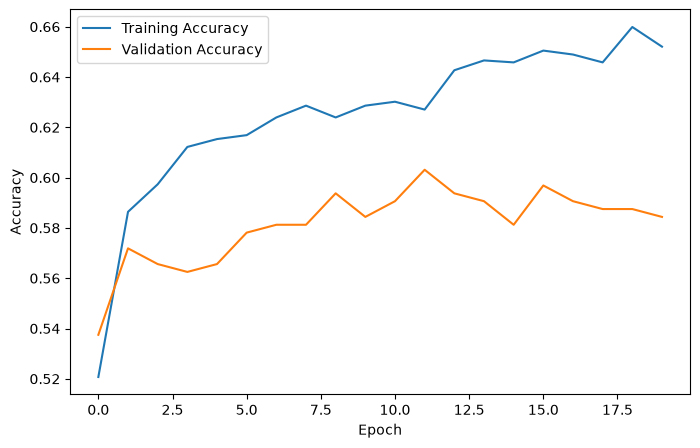

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

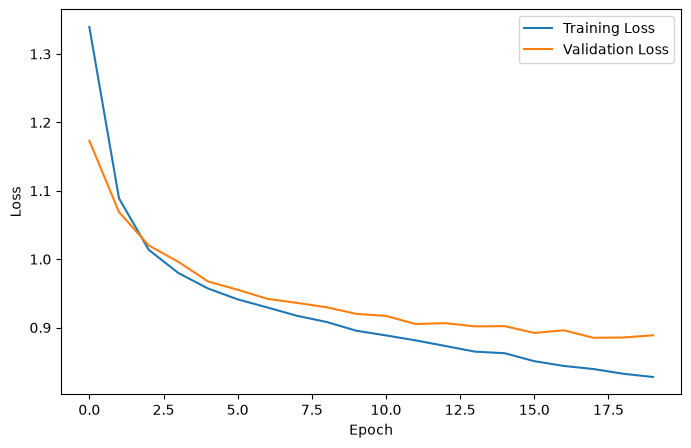

In [24]:
plt.figure(figsize=(8,5))

plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()